# Credit Card Fraud Detection

#### This project investigates the use of supervised machine learning models to detect fraudulent credit card transactions. Due to the highly imbalanced nature of the dataset, model performance is evaluated before and after applying random undersampling.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# 1. Load the Dataset & Get Info

In [3]:
credit_card_data = pd.read_csv("../data/creditcard.csv")

In [4]:
# First 5 rows of the dataset
credit_card_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# Last 5 rows of the dataset
credit_card_data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [6]:
# Dataset Information
credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
# Number of Genuine and Fraudulent Transactions 
credit_card_data['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

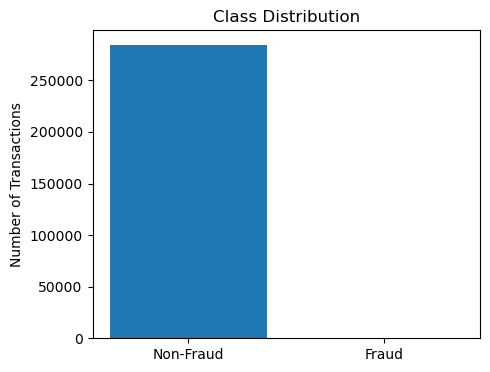

In [8]:
counts = credit_card_data['Class'].value_counts()
plt.figure(figsize=(5,4))
plt.bar(['Non-Fraud','Fraud'], counts)
plt.title("Class Distribution")
plt.ylabel("Number of Transactions")
plt.show()

##### The class distribution shows that legitimate transactions vastly outnumber fraudulent transactions, demonstrating a large class imbalance. This imbalance can cause machine learning models to favour the majority class and achieve high accuracy while failing to detect fraud.

# 2. Scaling and Removing Duplicates

In [9]:
sc = StandardScaler()

#Standardising 'Amount' Values to Address Skewness
credit_card_data['Amount'] = sc.fit_transform(pd.DataFrame(credit_card_data['Amount']))

In [10]:
credit_card_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,0


In [11]:
# Checking for any Duplicates 
credit_card_data.duplicated().any()

np.True_

In [12]:
data = credit_card_data.drop_duplicates()

In [13]:
data.shape

(283726, 31)

# 3. Split Data into Training and Testing Set

In [14]:
X = data.drop('Class', axis=1)
y = data['Class']

#dropping the Class column from X

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#test size is the percentage of data set aside for testing
#random state ensures reproducible results

In [16]:
# Using two classifiers to compare metrics and see which performs better

X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)
#scales features

results = []

classifier = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest Classifier": RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
}

for name, clf in classifier.items():
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    results.append({
        "Model": name,
        "Dataset": "Original",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df = results_df.round(3)

results_df

,Model,Dataset,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,Original,0.999,0.893,0.556,0.685
1,Random Forest Classifier,Original,1.000,0.970,0.722,0.828


##### These metrics show us that the model has high accuracy and precision, but lacks in recall and F1 score

Text(0.5, 1.0, 'Confusion Matrix')

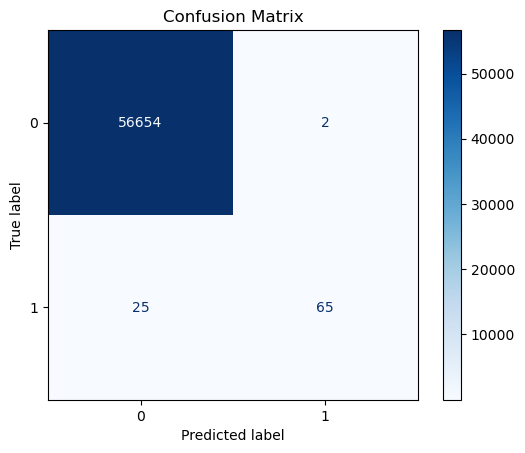

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")

##### The confusion matrix illustrates how the model classified legitimate and fraudulent transactions. While the model correctly identified most legitimate transactions, it missed several fraudulent transactions.

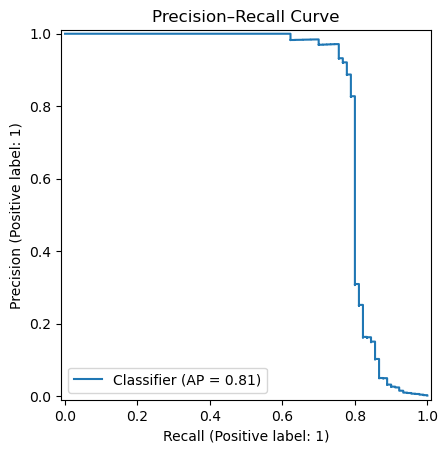

In [18]:
from sklearn.metrics import PrecisionRecallDisplay

y_scores = clf.predict_proba(X_test_scaled)[:, 1]

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_scores
)

plt.title("Precision–Recall Curve")
plt.show()

##### The Precision-Recall curve evaluates the model's ability to detect fraud across different thresholds. It is better suited to highly-imbalanced data, compared to accuracy, because it focuses on the balance between correctly identifying fraud (recall) and minimizing false positives (precision). We can improve the AP score by undersampling:

# 4. Undersampling to Improve Metrics

In [19]:
genuine = data[data['Class']==0]
fraud = data[data['Class']==1]

In [20]:
genuine.shape

(283253, 31)

In [21]:
fraud.shape

(473, 31)

In [22]:
genuine_sample = genuine.sample(n=473)
#taking a smaller sample

In [23]:
new_data = pd.concat([genuine_sample,fraud], ignore_index=True)
#create a new dataset with the smaller "genuine" sample

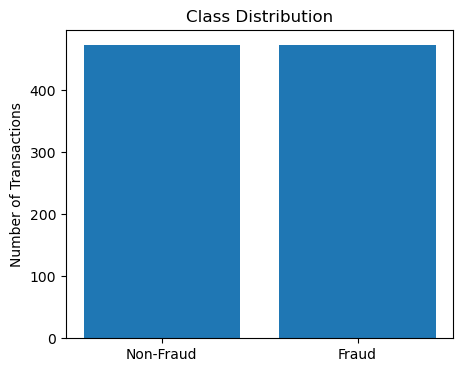

In [24]:
counts = new_data['Class'].value_counts()
plt.figure(figsize=(5,4))
plt.bar(['Non-Fraud','Fraud'], counts)
plt.title("Class Distribution")
plt.ylabel("Number of Transactions")
plt.show()

##### After undersampling, the dataset contains an equal number of fraudulent and legitimate transactions, producing a balanced training set.

# 5. Training and Testing with New Dataset

In [26]:
X = new_data.drop('Class', axis=1)
y = new_data['Class']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [28]:
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

classifier = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest Classifier": RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
}

for name, clf in classifier.items():
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    results.append({
    "Model": name,
    "Dataset": "Undersampled",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred)
})

results_df = pd.DataFrame(results)
results_df = results_df.round(3)

results_df

,Model,Dataset,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,Original,0.999,0.893,0.556,0.685
1,Random Forest Classifier,Original,1.000,0.970,0.722,0.828
2,Logistic Regression,Undersampled,0.937,0.969,0.912,0.939
3,Random Forest Classifier,Undersampled,0.937,0.979,0.902,0.939


##### After undersampling, the recall and F1 score has increased.

Text(0.5, 1.0, 'Confusion Matrix')

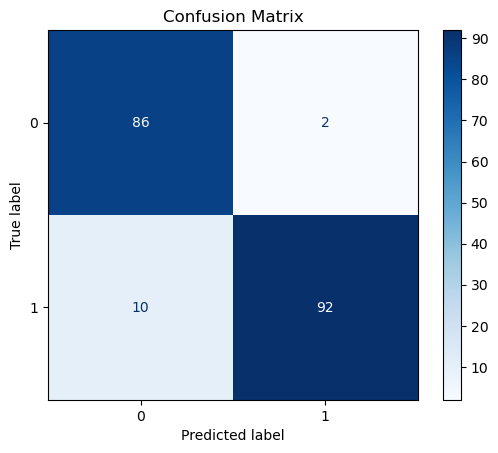

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")

##### This confusion matrix shows that the model identifies a greater proportion of fraudulent transactions, although this may come at the cost of producing more false positives.

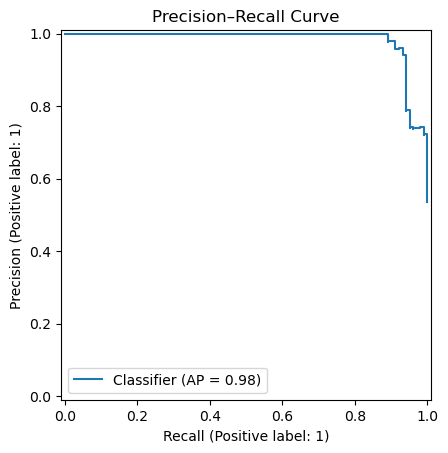

In [30]:
from sklearn.metrics import PrecisionRecallDisplay

y_scores = clf.predict_proba(X_test_scaled)[:, 1]

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_scores
)

plt.title("Precision–Recall Curve")
plt.show()

##### This curve remains closer to the upper-right corner indicating a stronger performance. The newer model identifies a greater proportion of fraudulent transactions and achieves a higher AP score from 0.81 to 0.98

# 6. Results & Conclusion

In [32]:
results_df = pd.DataFrame(results).round(3)
results_df

,Model,Dataset,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,Original,0.999,0.893,0.556,0.685
1,Random Forest Classifier,Original,1.000,0.970,0.722,0.828
2,Logistic Regression,Undersampled,0.937,0.969,0.912,0.939
3,Random Forest Classifier,Undersampled,0.937,0.979,0.902,0.939


##### The summary table provides an overall comparison of each model before and after undersampling using multiple evaluation metrics. While the original models achieved higher accuracy, the undersampled models generally improved recall and F1-score, indicating better detection of fraudulent transactions. These findings demonstrate the importance of considering multiple evaluation metrics when assessing models for highly imbalanced classification problems.